# Homogeneous Square

In [1]:
%load_ext autoreload
%autoreload 2
    
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('forkserver')

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad
import pandas as pd

from ttnte.xs.benchmarks import Server
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import gmres
from ttnte.cad import Patch
from ttnte.sources import IsotropicInternalSource
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 4096

# Get XS data
total = 1  # 1/cm
scattering_ratio = 0.9
xs_server = Server(
    {
        "Source": {
            "total": np.array([total]),
            "scatter_gtg": np.array([[[total * scattering_ratio]]]),
        }
    }
)

In [3]:
# Create NURBS geometry
length = 10 # cm
points = np.array(
    [
        [-length / 2, -length / 2, 0],
        [length / 2, -length / 2, 0],
        [-length / 2, length / 2, 0],
        [length / 2, length / 2, 0],
    ]
).reshape((2, 2, -1))
patch = Patch(cad.bilinear(points), "Source")

# Add uniform source of 1/cm to patch
source = IsotropicInternalSource(np.ones((1, *patch.shape)))
patch.set_source(source)

# Create mesh
mesh = IGAMesh()
mesh.add_patch(patch)

# Refine mesh resolution
mesh.refine(factor=13, degree=3)

# Connect patches
mesh.connect()

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=1, reflective_boundaries=False)
  -> Patch(material=Source, source=IsotropicInternalSource, id=0, name=None, shape=(16, 16), backend=geomdl)

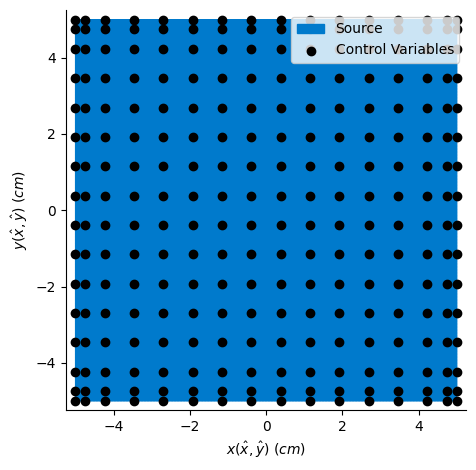

In [4]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/square.png", dpi=300)
plt.show()

## Assemble Matrix and TT Operators

In [5]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
mats = assembler.build()

# Save TT information
assembler.save_info("./coo_info.csv")

# Create operators in COO format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
tts = assembler.build(use_tt=False, eps=1e-10, q=False)

# Save TT information
assembler.save_info("./tt_info.csv")

Running MatrixAssembler.build()
Discretization: N = 4096, G = 1, P = 1, A = 16, B = 16
Operators: H, S, q, B_out
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 45.15 s)
Step            Shape                     Compression
H               1048576,1048576             13252.15
S               1048576,1048576           15775821.11
q               1048576                         1.00
B_out           1048576,1048576            410451.61
Running TTAssembler.build()
Discretization: N = 4096, G = 1, P = 1, A = 16, B = 16
Operators: H, S, B_out
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 7.59 s)
Step            Ranks                     Compression
H               3,3,3,2                   53561556.30
S               1,1,1,1                   426829048.05
B_out           3,4,4,3                   33768784.64


## Solve

In [6]:
# Run fixed source calculation
psi = gmres(
    A=(tts.H + tts.B_out - tts.S),
    b=mats.q,
    tol=1e-6,
    gpu_idx=0,
    maxiter=250,
    restart=50,
)[0].reshape(assembler.discretization)

# Save solution
mesh.save(path="mesh.hdf5", solution=psi)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

Running batched GMRES on GPU 0
-- (1): |r| = 0.517139555542, |r|/|b| = 0.001162188629, Elapsed Time = 0.380 s
-- (2): |r| = 0.059297558614, |r|/|b| = 0.000133261801, Elapsed Time = 0.692 s
-- (3): |r| = 0.016538452131, |r|/|b| = 0.000037167532, Elapsed Time = 1.004 s
-- (4): |r| = 0.006293451496, |r|/|b| = 0.000014143528, Elapsed Time = 1.320 s
-- (5): |r| = 0.002873532837, |r|/|b| = 0.000006457807, Elapsed Time = 1.632 s
-- (6): |r| = 0.001370164239, |r|/|b| = 0.000003079225, Elapsed Time = 1.946 s
-- (7): |r| = 0.000636217058, |r|/|b| = 0.000001429796, Elapsed Time = 2.258 s
-- (8): |r| = 0.000261481519, |r|/|b| = 0.000000587638, Elapsed Time = 2.568 s
-- Converged!


## Plotting and Comparison to OpenMC

In [7]:
leakage_frac_openmc = [0.42095701399999963, 2.2038687252709062e-05]
phi_mc = np.load("./openmc/data/mesh_flux.npy")
phi_mc_stdev = np.load("./openmc/data/mesh_stdev.npy")

leakage = assembler.outward_current(psi)
production = assembler.total_production()
leakage_frac = float(leakage / production)
print(f"TIDG leakage fraction = {leakage_frac}")
print(f"OpenMC leakage fraction = {leakage_frac_openmc[0]} +/- {leakage_frac_openmc[1]}")
print(f"Difference = {leakage_frac - leakage_frac_openmc[0]}")
print(f"TIDG is {(leakage_frac - leakage_frac_openmc[0]) / leakage_frac_openmc[1]} stdevs from OpenMC")

TIDG leakage fraction = 0.4209670032273035
OpenMC leakage fraction = 0.42095701399999963 +/- 2.2038687252709062e-05
Difference = 9.989227303885961e-06
TIDG is 0.4532587258643573 stdevs from OpenMC


<Figure size 640x480 with 0 Axes>

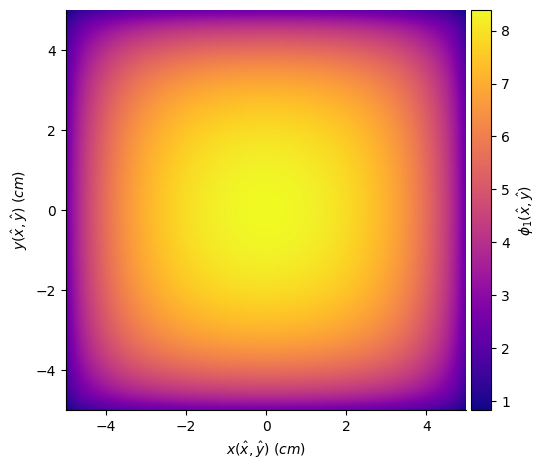

In [8]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(5, 5))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax, cbar = mesh.plot(plot_ctrlpts=False)
    cbar.set_label(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}.png", dpi=300)
    plt.show()

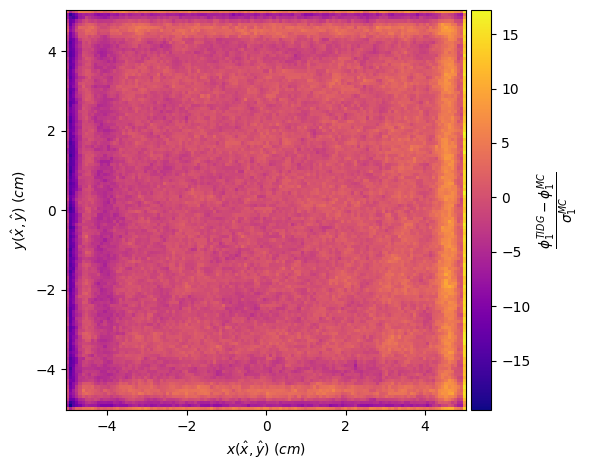

In [9]:
# Regular mesh
X, Y = np.meshgrid(
    np.linspace(-5, 5, phi_mc.shape[1]),
    np.linspace(-5, 5, phi_mc.shape[2]),
)

# Calculate z-score within each voxel
z = (phi_avg - phi_mc) / phi_mc_stdev
stats = {
    "Group": list(range(1, xs_server.num_groups + 1)) + ["Total"],
    **{
        name: np.zeros(xs_server.num_groups + 1) 
        for name in 
        ["Minimum", "Q1", "Median", "Q2", "Maximum", "Mean", "L2 Error"]
    },
}

for g in range(xs_server.num_groups):    
    # Plot z-score
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(X, Y, z[g,], cmap="plasma")
    divider = make_axes_locatable(ax)
    cbar = plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
    )
    cbar.set_label(
        "$\\frac{\\phi^{TIDG}_{" 
        + str(g + 1) 
        + "} - \\phi^{MC}_{"
        + str(g + 1) 
        + "}}{\\sigma^{MC}_{"
        + str(g + 1) 
        + "}}$", 
        size=14
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_zscore.png", dpi=300)
    plt.show()

    # Get some stats
    stats["Minimum"][g] = np.min(z[g,])
    stats["Q1"][g] = np.percentile(z[g,], 25)
    stats["Median"][g] = np.median(z[g,])
    stats["Q2"][g] = np.percentile(z[g,], 75)
    stats["Maximum"][g] = np.max(z[g,])
    stats["Mean"][g] = np.mean(z[g,])

stats["Minimum"][-1] = np.min(z)
stats["Q1"][-1] = np.percentile(z, 25)
stats["Median"][-1] = np.median(z)
stats["Q2"][-1] = np.percentile(z, 75)
stats["Maximum"][-1] = np.max(z)
stats["Mean"][-1] = np.mean(z)

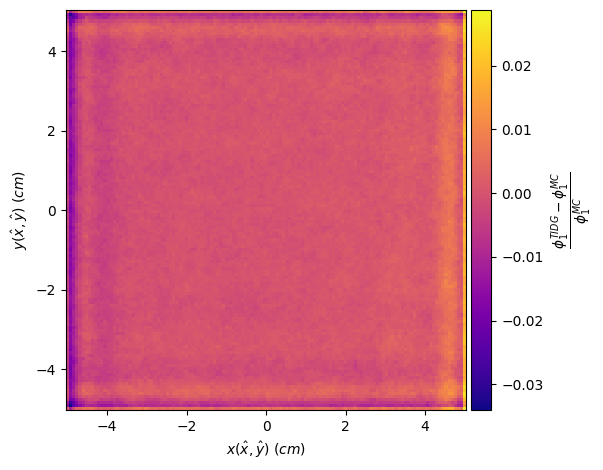

,Group,Minimum,Q1,Median,Q2,Maximum,Mean,L2 Error
0,1,-19.561154,-1.264932,-0.020201,1.220779,17.209393,-0.075083,0.001896
1,Total,-19.561154,-1.264932,-0.020201,1.220779,17.209393,-0.075083,0.001896


In [10]:
relative_error = (phi_avg - phi_mc) / phi_mc

for g in range(xs_server.num_groups):    
    # Plot z-score
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(X, Y, relative_error[g,], cmap="plasma")
    divider = make_axes_locatable(ax)
    cbar = plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
    )
    cbar.set_label(
        "$\\frac{\\phi^{TIDG}_{" 
        + str(g + 1) 
        + "} - \\phi^{MC}_{"
        + str(g + 1) 
        + "}}{\\phi^{MC}_{"
        + str(g + 1) 
        + "}}$", 
        size=14
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_error.png", dpi=300)
    plt.show()

    # Calculate L2-error
    stats["L2 Error"][g] = (
        np.linalg.norm((phi_avg[g,] - phi_mc[g,]).flatten(), 2) 
        / np.linalg.norm(phi_mc[g,].flatten(), 2)
    )

stats["L2 Error"][-1] = (
    np.linalg.norm((phi_avg - phi_mc).flatten(), 2) 
    / np.linalg.norm(phi_mc.flatten(), 2)
)
pd.DataFrame(stats)